<a href="https://colab.research.google.com/github/Kavia-M/Data_science_course-Intellipaat/blob/main/Python/Classwork/Trainers_notes/Modules/Case_Study/US_HoneyCD_by_Trainer(17th_June).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Dataset Link: https://drive.google.com/file/d/1tdvHU6hzWF0v4l7s3n70Xb3bwBebCCtO/view?usp=sharing

In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/US_honey_dataset (1).csv')

#Problem statement:
The dataset provided contains information on US Honey Consumption, including the average price of honey. We aim to explore and analyze this data to identify the trends and patterns in the average honey price and gain insights into its fluctuation overtime.

In [ ]:
df

,Unnamed: 0,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
0,0,Alabama,16000,58,928000,28000,62.00,575000,1995
1,1,Arizona,52000,79,4108000,986000,68.00,2793000,1995
2,2,Arkansas,50000,60,3000000,900000,64.00,1920000,1995
3,3,California,420000,93,39060000,4687000,60.00,23436000,1995
4,4,Colorado,45000,60,2700000,1404000,68.00,1836000,1995
...,...,...,...,...,...,...,...,...,...
1110,1110,Virginia,6000,40,79000,79000,8.23,1975000,2021
1111,1111,Washington,96000,32,1206000,1206000,2.52,7741000,2021
1112,1112,WestVirginia,6000,43,136000,136000,4.80,1238000,2021
1113,1113,Wisconsin,42000,47,750000,750000,2.81,5547000,2021


In [ ]:
df.info() #Summary of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           1115 non-null   int64  
 1   state                1115 non-null   object 
 2   colonies_number      1115 non-null   int64  
 3   yield_per_colony     1115 non-null   int64  
 4   production           1115 non-null   int64  
 5   stocks               1115 non-null   int64  
 6   average_price        1115 non-null   float64
 7   value_of_production  1115 non-null   int64  
 8   year                 1115 non-null   int64  
dtypes: float64(1), int64(7), object(1)
memory usage: 78.5+ KB


In [ ]:
df.drop("Unnamed: 0", axis=1,inplace=True) #inplace: permanent changes
df

,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
0,Alabama,16000,58,928000,28000,62.00,575000,1995
1,Arizona,52000,79,4108000,986000,68.00,2793000,1995
2,Arkansas,50000,60,3000000,900000,64.00,1920000,1995
3,California,420000,93,39060000,4687000,60.00,23436000,1995
4,Colorado,45000,60,2700000,1404000,68.00,1836000,1995
...,...,...,...,...,...,...,...,...
1110,Virginia,6000,40,79000,79000,8.23,1975000,2021
1111,Washington,96000,32,1206000,1206000,2.52,7741000,2021
1112,WestVirginia,6000,43,136000,136000,4.80,1238000,2021
1113,Wisconsin,42000,47,750000,750000,2.81,5547000,2021


In [ ]:
df.isnull().sum()

,0
state,0
colonies_number,0
yield_per_colony,0
production,0
stocks,0
average_price,0
value_of_production,0
year,0


In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
#let's pretend we had null values
#df.dropna(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#let's pretend we had duplicates values
#df.drop_duplicates(inplace=True)

# **1) Which states are rarely contributing to honey production for the last 27 years?**

In [ ]:
#groupby: groups data into buckets of some category, which can then be used to do anything on each bucket

In [ ]:
cont=df.groupby(["state"])["production"].sum().reset_index()

In [ ]:
cont

,state,production
0,Alabama,14467000
1,Arizona,38844000
2,Arkansas,51846000
3,California,423876000
4,Colorado,32660000
5,Florida,280934000
6,Georgia,57426000
7,Hawaii,15420000
8,Idaho,87188000
9,Illinois,9864000


In [ ]:
RarCont=cont.sort_values(by='production', ascending=True).head()
RarCont

,state,production
16,Maryland,1975000
30,Oklahoma,2055000
33,SouthCarolina,2823000
13,Kentucky,3224000
15,Maine,4762000


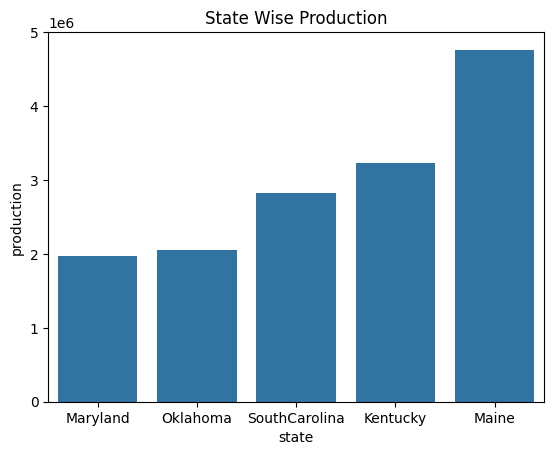

In [ ]:
sns.barplot(data=RarCont, x='state', y='production')
plt.title('State Wise Production')
plt.xlabel('state')
plt.ylabel('production')
plt.show()

#**2) Which are the top 5 Honey producing states in the US?**


In [ ]:
topCont=df.groupby(["state"])["production"].sum().reset_index()

In [ ]:
topCont

,state,production
0,Alabama,14467000
1,Arizona,38844000
2,Arkansas,51846000
3,California,423876000
4,Colorado,32660000
5,Florida,280934000
6,Georgia,57426000
7,Hawaii,15420000
8,Idaho,87188000
9,Illinois,9864000


In [ ]:
top5=topCont.sort_values(by="production", ascending=True).tail()
top5

,state,production
21,Montana,197173000
5,Florida,280934000
34,SouthDakota,355726000
3,California,423876000
28,NorthDakota,513742000


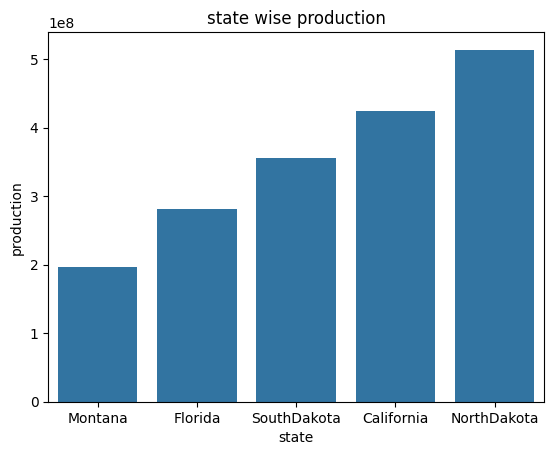

In [ ]:
sns.barplot(data=top5, x="state", y="production")
plt.title('state wise production')
plt.xlabel('state')
plt.ylabel('production')
plt.show()

# 3) **What  is the Change in mean Average price of Honey from 1995 to 2021?**

In [ ]:
mean_avg=df.groupby(['year'])['average_price'].mean() #average of average_price column

In [ ]:
mean_avg

,average_price
year,
1995,74.840909
1996,99.568182
1997,91.325581
1998,83.720930
1999,80.325581
2000,79.023256
2001,88.465116
2002,133.204545
2003,151.068182


In [ ]:
change_mean=mean_avg.loc[1995]-mean_avg.loc[2021]

In [ ]:
change_mean

np.float64(71.5066590909091)

# **4) Which was the year when production of Honey in whole US was the highest?**

In [ ]:
highestProd=df.groupby(['year'])['production'].sum().reset_index()

In [ ]:
highestProd

,year,production
0,1995,210272000
1,1996,197995000
2,1997,191176000
3,1998,219321000
4,1999,204585000
5,2000,220320000
6,2001,185403000
7,2002,170732000
8,2003,180741000
9,2004,182379000


In [ ]:
high_sorted=highestProd.sort_values(by='production', ascending=False)

In [ ]:
high_sorted.head(1)

,year,production
5,2000,220320000


#**5.From the above inference we get the production was highest in the year 2000, now get for which state was having highest contribution in that year**

In [ ]:
highProdState=df.groupby(['state','year'])['production'].sum().reset_index()
highProdState

,state,year,production
0,Alabama,1995,928000
1,Alabama,1996,1024000
2,Alabama,1997,924000
3,Alabama,1998,1136000
4,Alabama,1999,1156000
...,...,...,...
1110,Wyoming,2017,186000
1111,Wyoming,2018,175000
1112,Wyoming,2019,306000
1113,Wyoming,2020,608000


In [ ]:
state_2000_Prod=highProdState.loc[(highProdState['year']==2000)]

In [ ]:
state_2000_Prod

,state,year,production
5,Alabama,2000,1248000
32,Arizona,2000,2360000
59,Arkansas,2000,5115000
86,California,2000,30800000
113,Colorado,2000,1740000
140,Florida,2000,24360000
167,Georgia,2000,3135000
194,Hawaii,2000,784000
221,Idaho,2000,4700000
248,Illinois,2000,488000


In [ ]:
state_2000_Prod.sort_values(by='production', ascending=False).head(1)

,state,year,production
721,NorthDakota,2000,33350000


# **6.Which states have the highest no.of colonies in the year 2000?**